In [ ]:
import scanpy as sc
import pandas as pd
import os
import re
import numpy as np
import anndata as ad
import cell2location
from cell2location.models import CoLocatedGroupsSklearnNMF
from scipy.optimize import linear_sum_assignment

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

visium_dir = '../../../data/GBM_LEAP_annotations/web_atlas/anndata/'
visium_files = [f for f in os.listdir(visium_dir) if f.endswith('.h5ad')]
tumours = list(set([re.sub('-.*$', '', i) for i in visium_files]))

In [ ]:
tumour_adata = {}
for tumour in tumours:
    print(tumour)
    tumour_files = [i for i in visium_files if tumour in i]

    adatas = []
    for visium_file in tumour_files:
        visium_dir+visium_file
        adata = sc.read_h5ad(visium_dir+visium_file)
        adata = adata[:,adata.var['feature_types']=='Cell state abundances']
        adatas.append(adata)
    tumour_adata[tumour] = ad.concat(adatas, label="sample", merge="unique", 
                      uns_merge="unique", index_unique="_")
    tumour_adata[tumour].obsm['q05_cell_abundance_w_sf'] = extract_feature(tumour_adata[tumour], 
                                                                             'Cell state abundances').dropna()
    
    factor_names = np.array(tumour_adata[tumour].obsm['q05_cell_abundance_w_sf'].columns.tolist())
    tumour_adata[tumour].uns['mod'] = {}
    tumour_adata[tumour].uns['mod']['factor_names'] = factor_names
    

AT3


/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/sit

AT5


/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/sit

AT6


...

/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/sit

AT9


/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/sit

AT12


/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/miniconda3/envs/cell2loc_env/lib/python3.10/sit

# Run NMF

In [ ]:
from cell2location import run_colocation

output_dir = '../../../data/GBM_LEAP_annotations/cell2location/NMF/'

# decide on these factors:
factor_range = [10, 12 ,14, 16, 20, 25, 30, 40, 50]

/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/soft

In [ ]:
res_dict = {}
for key in tumour_adata:

    # go to relevant directory
    os.makedirs(output_dir+key, exist_ok = True)
    os.chdir(output_dir+key)

    # run analysis
    res_dict[key], tumour_adata[key] = run_colocation(
                   tumour_adata[key], model_name='CoLocatedGroupsSklearnNMF',
                   verbose=False, return_all=True,

                   train_args={
                    'n_fact': factor_range, 
                    'n_iter': 20000,

                    'sample_name_col': 'sample_name', # columns in adata_vis.obs that identifies sample

                    'mode': 'normal',
                    'n_type': 'restart', 'n_restarts': 10
                   },

                   model_kwargs={'init': 'random', 
                                 'random_state': 0, 'nmf_kwd_args': {'tol': 0.00001}})

# Load cell2location NMF models

In [ ]:
import glob
import pickle
import itertools

def calculate_stability_metrics(mod_dict, factor_list):

    # Unique name-based comparisons
    pairs = list(itertools.combinations(mod_dict.keys(), 2))
    
    # get mean max correlation per comparison
    stability_dict = {}
    for pair in pairs:
            # from cell2loc stability code:
            fac1 = mod_dict[pair[0]]
            fac2 = mod_dict[pair[1]]

            corr12 = np.corrcoef(fac1, fac2, False)
            ind_top = np.arange(0, fac1.shape[1])
            ind_right = np.arange(0, fac1.shape[1]) + fac1.shape[1]
            corr12 = corr12[ind_top, :][:, ind_right]
            corr12[np.isnan(corr12)] = 0

            #import matplotlib.pyplot as plt
            #plt.imshow(corr12[:, linear_sum_assignment(2 - corr12)[1]])

            # summary stat
            stability_dict[pair] = np.max(corr12, axis=1).mean()
    return pd.DataFrame.from_dict(stability_dict, 
                                  orient="index", 
                                  columns=[pairs])

In [ ]:
factor_list = ['n_fact{}'.format(str(i)) for i in factor_range]

In [ ]:
stability_metrics_all = []
for tumour in tumours:

    # load model output
    model_directory = '../../../data/GBM_LEAP_annotations/cell2location/NMF/{}/*/models/*p'.format(tumour)
    files = glob.glob(model_directory)

    stability_metrics = []
    # iterate through files
    for file in files:
        # extract factor name
        factor = re.sub('^.*/model_(.*?).p', '\\1', file)
        
        # load model:
        try:
            with open(file, "rb") as f:
                nmf_model = pickle.load(f)
        except Exception:
            print("{}, {} missing".format(tumour, file))
            pass

        # Get unique pairs for a dict of model outputs
        repeats = nmf_model['mod'].results.keys()
        fac_dict = {}
        for init in repeats:
            fac_dict[init] = nmf_model['mod'].results[init]['post_sample_means']['cell_type_factors']

        try:
            metrics = calculate_stability_metrics(fac_dict, factor_list)
            stability_metrics.append(metrics)
        except:
            print("{}, {} issue calculating metrics.".format(tumour, file))
        
    stability_metrics = pd.concat(stability_metrics, axis=1)
    
    stability_metrics['tumour'] = tumour
    stability_metrics_all.append(stability_metrics)

/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using versio

In [ ]:
df = pd.concat(stability_metrics_all)\
.reset_index()\
.melt(id_vars=['tumour', 'index'])
df['Factors'] = [int(re.sub('n_fact', '', i)) for i in df['variable']]
df["tumour"] = pd.Categorical(df["tumour"], categories=tumours)
df = df.sort_values(['tumour', 'index']).reset_index(drop=True)

df = df[df['tumour']!='AT12'] # not finished yet

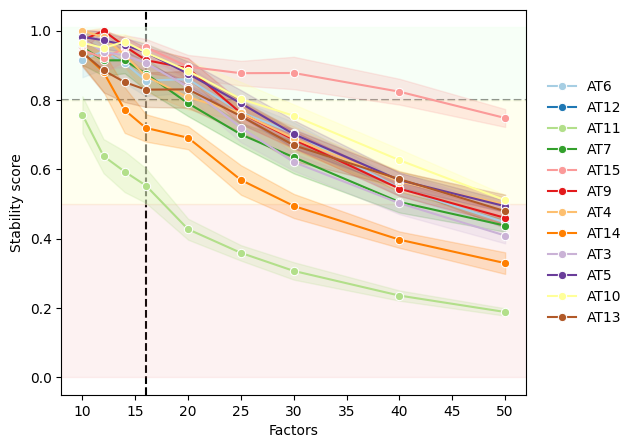

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.figure(figsize=(6,5))

sns.lineplot(data=df, x="Factors", y="value", hue = 'tumour',
             errorbar="sd", marker="o", palette = 'Paired')
plt.axvline(16, linestyle = '--', color = 'black', zorder=-1)
plt.axhline(0.8, linestyle = '--', color = 'black', zorder=-1)

xmin=df['value'].min()-1
xmax=df['value'].max()+1

plt.axhspan(xmin=xmin, xmax=xmax, ymin=0.8, ymax=1.01, 
            color = 'honeydew', alpha=0.5, zorder=-1)
plt.axhspan(xmin=xmin, xmax=xmax, ymin=0.5, ymax=0.8, 
            color = 'lightyellow', alpha=0.5, zorder=-1)
plt.axhspan(xmin=xmin, xmax=xmax, ymin=0, ymax=0.5, 
            color = 'lightcoral', alpha=0.1, zorder=-1)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.ylabel("Stability score")

plt.savefig('../plots/stability_metrics.pdf')